\setcounter{secnumdepth}{0}

# Problem Set 4

## Om Mehta

## FINM 34700

In [84]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import f
from sklearn.metrics import pairwise_distances
import prince
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

### 1. *Simple* MANOVA *layout*

### a)

\begin{align*}
\bar{\boldsymbol{x_1}} = \frac{48}{12} = 4 \\ \\ \bar{\boldsymbol{x_2}} = \frac{60}{12} = 5 \\ \\
\end{align*}

\begin{align*}
x_1 = \begin{bmatrix}
6 & 5 & 8 & 4 & 7 \\ 3 & 1 & 2 \\ 2 & 5 & 3 & 2
\end{bmatrix}
= 4 \begin{bmatrix}
1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 & 1 
\end{bmatrix} + \begin{bmatrix} 2 & 2 & 2 & 2 & 2 \\ -2 & -2 & -2 \\ -1 & -1 & -1 & -1 \end{bmatrix} + \begin{bmatrix} 0 & -1 & 2 & -2 & 1 \\ 1 & -1 & 0 \\ -1 & 2 & 0 & -1 \end{bmatrix}
\end{align*}

\begin{align*}
x_2 = \begin{bmatrix}
7 & 9 & 6 & 9 & 9 \\ 3 & 6 & 3 \\ 3 & 1 & 1 & 3
\end{bmatrix}
= 5 \begin{bmatrix}
1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 & 1 
\end{bmatrix} + \begin{bmatrix} 3 & 3 & 3 & 3 & 3 \\ -1 & -1 & -1 \\ -3 & -3 & -3 & -3 \end{bmatrix} + \begin{bmatrix} -1 & 1 & -2 & 1 & 1 \\ -1 & 2 & -1 \\ 1 & -1 & -1 & 1 \end{bmatrix}
\end{align*}

### b)

In [95]:
x1 = [
    [6, 5, 8, 4, 7],      
    [3, 1, 2],            
    [2, 5, 3, 2]          
]

x2 = [
    [7, 9, 6, 9, 9],  
    [3, 6, 3],        
    [3, 1, 1, 3]      
]

X = []
groups = []
for g, (g1, g2) in enumerate(zip(x1, x2), start=1):
    for i in range(len(g1)):
        X.append([g1[i], g2[i]])
        groups.append(g)

X = np.array(X)
groups = np.array(groups)

x_bar = X.mean(axis=0)

group_means = {}
for g in np.unique(groups):
    group_means[g] = X[groups == g].mean(axis=0)

W = np.zeros((2, 2))
for g in np.unique(groups):
    Xg = X[groups == g]
    mean_g = group_means[g]
    residuals = Xg - mean_g
    W += residuals.T @ residuals

B = np.zeros((2, 2))
for g in np.unique(groups):
    n_g = np.sum(groups == g)
    diff = (group_means[g] - x_bar).reshape(2, 1)
    B += n_g * (diff @ diff.T)

T = W + B
wilks_lambda = np.linalg.det(W) / np.linalg.det(T)

np.linalg.det(W), np.linalg.det(B), wilks_lambda

(155.00000000000003, 720.0000000000001, 0.0361895867382676)

### d)

In [96]:
p = 2  # number of dependent variables
g = 3  # number of groups
n = 12  # total number of observations

scaling_factor = n - 1 - (p + g) / 2
chi_square_stat = -np.log(wilks_lambda) * scaling_factor
df = p * (g - 1)

# Compute p-value
p_value = 1 - stats.chi2.cdf(chi_square_stat, df)

chi_square_stat, df, p_value

(28.21136281591705, 4, 1.1301100103167094e-05)

### e)

\begin{align*}
(H_0): {\mu}_1 = {\mu}_2 = {\mu}_3 \\
(H_a): \text{At least one } {\mu}_t \text{ differs from the others}
\end{align*}

In words: \
The null hypothesis states that the mean vectors of the two responses (i.e., $x_1$ and $x_2$) are the same across all three treatment groups. That is, the treatments have no overall multivariate effect on the outcomes. \\
The alternative hypothesis states that at least one treatment group differs in its mean vector — meaning there is a significant difference in the combined responses ($x_1$, $x_2$) across groups.

Since the p-value obtained from Bartlett’s approximation in part (d) is extremely small ($\approx 1.13 \times 10^{-5}$), we reject $H_0$. This provides strong evidence that the treatments have significantly different effects on the joint responses.

## 2. MANOVA *and confidence region*

In [97]:
df = pd.read_csv('T6-13.DAT', sep=r"\s+", header=None)
df.columns=['x1', 'x2', 'x3', 'x4', 'period']
per1, per2, per3 = df.loc[df['period']==1], df.loc[df['period']==2], df.loc[df['period']==3]

### a)

\begin{align*}
p = 4 \\ \\
g = 3 \\ \\ 
n_1 = n_2 = n_3 = 30
\end{align*}

### b)

\begin{align*}
H_0: \mu_1=\mu_2=\mu_3 \\ \\
H_a: \text{At least one } \mu \text{ differs from the rest}
\end{align*}

### c)

In [98]:
X = np.array(df)[:,:4]
total_mean = X.mean(axis=0)
labels = np.array(df['period'])
per1 = np.array(per1)[:,:4]
per2 = np.array(per2)[:,:4]
per3 = np.array(per3)[:,:4]
per1_mean = per1.mean(axis=0)
per2_mean = per2.mean(axis=0)
per3_mean = per3.mean(axis=0)
per1_residual = (per1 - per1_mean).T @ (per1 - per1_mean)
per2_residual = (per2 - per2_mean).T @ (per2 - per2_mean)
per3_residual = (per3 - per3_mean).T @ (per3 - per3_mean)
W = per1_residual + per2_residual + per3_residual
n = 30
B1 = n * np.outer(per1_mean - total_mean, per1_mean - total_mean)
B2 = n * np.outer(per2_mean - total_mean, per2_mean - total_mean)
B3 = n * np.outer(per3_mean - total_mean, per3_mean - total_mean)
B = B1 + B2 + B3
wilks = np.linalg.det(W) / np.linalg.det(W + B)
n = 90
p = 4
t1 = (n - p - 2) / p
lambda_root = np.sqrt(wilks)
f_stat = t1 * (1-lambda_root)/lambda_root
df1 = 2*p
df2 = 2*(n - p - 2)
p_value = 1 - f.cdf(f_stat, df2, df2)
wilks, p_value

(0.8301026836053987, 2.1744965631453894e-06)

\begin{align*}
\Lambda^* \approx 0.83 \\ \\
p \approx 2.17\cdot 10^{-6}
\end{align*}
At the 5% significance level, we reject $H_0$ that all means are equal, as the p-value is effectively 0. This means that at least one time period has significantly different skull measurements.

### d)

Assumptions for this F-statistic are **multivariate normality, homogeneity of covariance matrices, independence of observations, independent treatments, and $n>>p$ for all groups**

### e)

\begin{align*}
\binom{g}{2} \cdot p \Rightarrow \binom{3}{2} \cdot 4 = 12
\end{align*}

This is because you would only be doing pairwise tests **among 3 different groups**, and within the groups there are **4 variables**, each giving a separate confidence interval for the difference in means of each variable in each group.

## 3. Multidimensional Scaling

In [99]:
with open("T12-13.DAT") as f:
    raw = f.read().split()
    data = np.array([float(x) for x in raw])

mat = np.zeros((9, 9))
mat[np.triu_indices(9)] = data
X = mat.T
X = X + X.T

### a)

In [100]:
coords = []
for q in range(3, 6):
    mds = MDS(n_components=q, dissimilarity='precomputed', random_state=42)
    coords_q = mds.fit_transform(X)
    coords.append(coords_q)

In [101]:
for i, q in enumerate(range(3, 6)):
    print(f"\nCoordinates for q = {q} dimensions:")
    df = pd.DataFrame(coords[i], columns=[f"Dim{j+1}" for j in range(q)])
    df.index = [f"Site {k+1}" for k in range(len(coords[i]))]
    display(df)


Coordinates for q = 3 dimensions:


,Dim1,Dim2,Dim3
Site 1,0.303692,0.041876,0.743028
Site 2,-0.226884,-0.187009,-0.729506
Site 3,-0.050006,0.044434,0.495585
Site 4,-0.252788,0.733109,0.029408
Site 5,-1.196997,-0.073611,-0.172882
Site 6,0.152541,0.180823,0.512839
Site 7,0.147988,0.093412,-0.489832
Site 8,0.593933,-0.330486,-1.205757
Site 9,0.528522,-0.502548,0.817117



Coordinates for q = 4 dimensions:


,Dim1,Dim2,Dim3,Dim4
Site 1,0.236771,0.196308,0.653354,0.343573
Site 2,-0.195262,0.074840,-0.651011,-0.408250
Site 3,0.352628,0.064902,0.306252,0.154284
Site 4,0.039592,-0.649294,0.294356,-0.292802
Site 5,0.798425,-0.301308,-0.816544,-0.223575
Site 6,0.250259,0.262564,0.460954,-0.024642
Site 7,-0.449998,-0.217521,-0.120800,-0.186079
Site 8,-1.144534,0.256611,-0.682633,-0.240390
Site 9,0.112120,0.312898,0.556070,0.877881



Coordinates for q = 5 dimensions:


,Dim1,Dim2,Dim3,Dim4,Dim5
Site 1,-0.373791,0.305722,-0.137550,0.597623,-0.157964
Site 2,0.400671,-0.286404,0.260560,-0.562864,-0.114246
Site 3,-0.264515,0.349733,0.018894,0.228509,-0.049388
Site 4,0.209782,0.352122,-0.328352,-0.050999,0.555357
Site 5,-0.109934,0.475905,0.563750,-0.899244,0.316240
Site 6,-0.112486,0.363578,0.041336,0.342929,-0.227294
Site 7,0.335443,-0.324085,-0.205240,-0.125692,0.142527
Site 8,0.602949,-1.185384,0.006809,-0.309723,-0.186695
Site 9,-0.688120,-0.051186,-0.220207,0.779462,-0.278539


### b)

Stress(3) = 0.5224
Stress(4) = 0.5221
Stress(5) = 0.5220


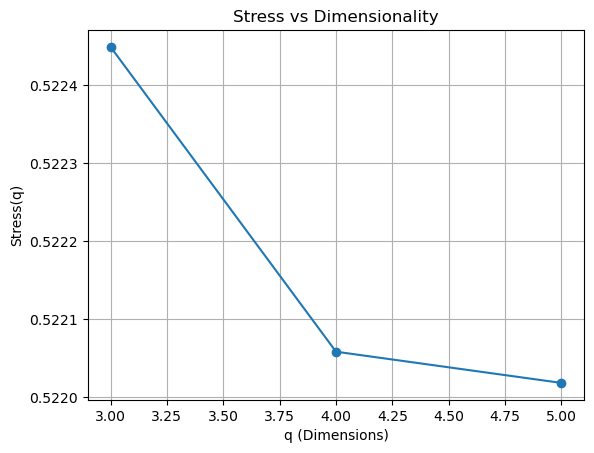

In [102]:
stress_vals = []

for i, q in enumerate(range(3, 6)):
    coords_q = coords[i]                     # Embedded coordinates for q dimensions
    d_q = pairwise_distances(coords_q)       # d_ij^(q)
    
    numerator = np.sum((X - d_q)**2) / 2      # Sum over j < i
    denominator = np.sum(X**2) / 2            # Sum over j < i
    stress = np.sqrt(numerator / denominator)
    
    stress_vals.append(stress)
    print(f"Stress({q}) = {stress:.4f}")
plt.plot(range(3, 6), stress_vals, marker='o')
plt.xlabel("q (Dimensions)")
plt.ylabel("Stress(q)")
plt.title("Stress vs Dimensionality")
plt.grid(True)
plt.show()

### c)

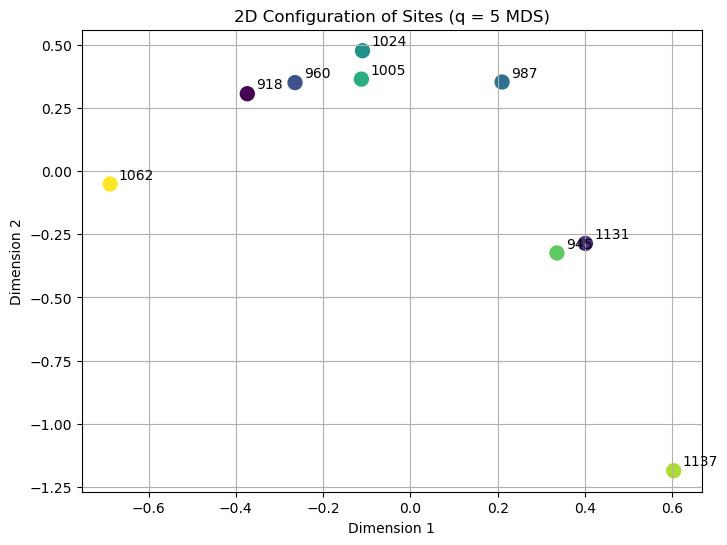

In [103]:
coords_5 = coords[2]  # 5D coordinates (q = 5)
periods = [918, 1131, 960, 987, 1024, 1005, 945, 1137, 1062]

x = coords_5[:, 0]  # First dimension
y = coords_5[:, 1]  # Second dimension

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=range(9), cmap='viridis', s=100)

for i, period in enumerate(periods):
    plt.text(x[i] + 0.02, y[i] + 0.02, str(period), fontsize=10)

plt.title("2D Configuration of Sites (q = 5 MDS)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

## 4. Correspondence Analysis

### a)

In [104]:
df = pd.read_csv('HairEyeAll.txt', sep=r'\s+', header=None)
df.index = ['Black', 'Brown', 'Red', 'Blond']
df.columns=['Brown', 'Blue', 'Hazel', 'Green']
df_copy = df.copy()

In [105]:
row_pcts = df.div(df.sum(axis=1), axis=0).round(2)
col_pcts = df.div(df.sum(axis=0), axis=1).round(2)
display(row_pcts, col_pcts)

,Brown,Blue,Hazel,Green
Black,0.63,0.19,0.14,0.05
Brown,0.42,0.29,0.19,0.10
Red,0.37,0.24,0.20,0.20
Blond,0.06,0.74,0.08,0.13


,Brown,Blue,Hazel,Green
Black,0.31,0.09,0.16,0.08
Brown,0.54,0.39,0.58,0.45
Red,0.12,0.08,0.15,0.22
Blond,0.03,0.44,0.11,0.25


### b)

In [106]:
df

,Brown,Blue,Hazel,Green
Black,68,20,15,5
Brown,119,84,54,29
Red,26,17,14,14
Blond,7,94,10,16


In [107]:
df['Total'] = df.sum(axis=1)
df.loc['Total'] = df.sum(axis=0)
n = df.loc['Total', 'Total']
row_totals = df.loc['Total'].drop('Total') 
col_totals = df['Total'].drop('Total')     

expected = np.outer(col_totals, row_totals) / n

# Convert to DataFrame for clarity
expected_df = pd.DataFrame(expected, index=df.index[:-1], columns=df.columns[:-1])
display(expected_df.round(2))

,Brown,Blue,Hazel,Green
Black,40.14,39.22,16.97,11.68
Brown,106.28,103.87,44.93,30.92
Red,26.39,25.79,11.15,7.68
Blond,47.20,46.12,19.95,13.73


### c)

In [108]:
cell_mass = (df_copy - expected_df)**2 / expected_df
display(cell_mass.round(2))

,Brown,Blue,Hazel,Green
Black,19.35,9.42,0.23,3.82
Brown,1.52,3.80,1.83,0.12
Red,0.01,2.99,0.73,5.21
Blond,34.23,49.70,4.96,0.38


In [109]:
chi2_stat = cell_mass.to_numpy().sum()
chi2_stat

138.28984162600824

The degrees of freedom of the $\chi$^2 is equal to $\text{(\# of rows - 1)} \cdot \text{(\# of columns - 1)} = 3 \cdot 3 = 9$.

**Total Intertia** = $\frac{\chi ^2}{9} \approx 15.37$

### d)

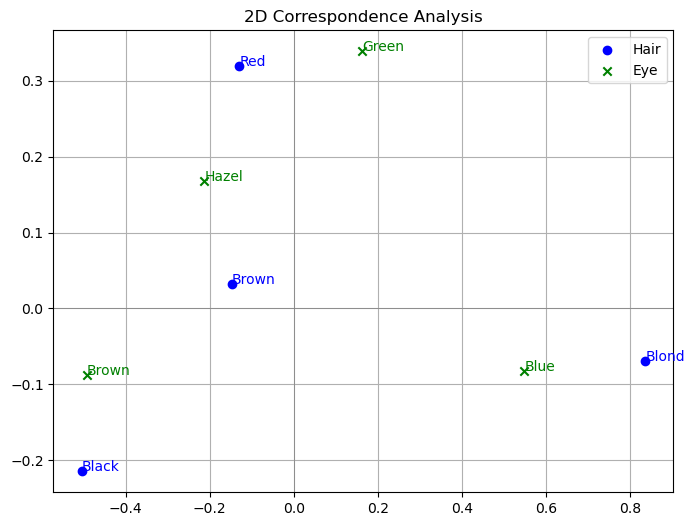

Explained inertia per dimension: [0.9037805836477717, 0.0962194163522283]
Total captured in 2D: 100.00%


In [89]:
df_ca = df.drop(index='Total').drop(columns='Total')

ca = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
ca = ca.fit(df_ca)

row_coords = ca.row_coordinates(df_ca)
col_coords = ca.column_coordinates(df_ca)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(row_coords[0], row_coords[1], c='blue', label='Hair')
for i, txt in enumerate(df_ca.index):
    ax.annotate(txt, (row_coords.iloc[i, 0], row_coords.iloc[i, 1]), color='blue')

ax.scatter(col_coords[0], col_coords[1], c='green', marker='x', label='Eye')
for i, txt in enumerate(df_ca.columns):
    ax.annotate(txt, (col_coords.iloc[i, 0], col_coords.iloc[i, 1]), color='green')

ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_title('2D Correspondence Analysis')
ax.legend()
plt.grid(True)
plt.show()

try:
    inertia = ca.explained_inertia_
except AttributeError:
    eigenvalues = ca.eigenvalues_
    total = sum(eigenvalues)
    inertia = [val / total for val in eigenvalues]

print("Explained inertia per dimension:", inertia)
print(f"Total captured in 2D: {sum(inertia):.2%}")

The 2-dimensional correspondence analysis explains $100\%$ of the total variation, with **Dimension 1 capturing $90.38\%$ and Dimension 2 capturing $9.62\%$.** The biplot shows **strong associations between Blond hair and Blue eyes, as well as Red hair and Green eyes.** The category **Hazel eyes** appears more centrally positioned, indicating it is less strongly associated with any specific hair color. The proximity of **Black hair and Brown eyes also suggests a notable pairing.** These findings reveal meaningful deviations from independence between hair and eye color categories.

## 5. Conditional Multivariate Normal

### a)

The general formula for conditional expectation of a multivariate normal random variable is given by:
\begin{align*}
\mathbb{E}[X_1|X_2=x_2]=\mu_1+ \Sigma_{12} \Sigma_{22}^{-1}(x_2-\mu_2)
\end{align*}
Using this, we can extend to include the second conditional $X_3=x_3$:
\begin{align*}
\mathbb{E}[X_1|X_2=x_2,X_3=x_3]=\mu_1+\Sigma_{12} \Sigma_{22}^{-1}(x_2-\mu_2)+\Sigma_{13} \Sigma_{33}^{-1}(x_3-\mu_3)
\end{align*}

### b)

The general formula for conditional variance of a multivariate normal random variable is given by:
\begin{align*}
Var(X_1|X_2=x_2) = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}
\end{align*}
Using this, we can extend to include the second conditional $X_3=x_3$:
\begin{align*}
Var(X_1|X_2=x_2) = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21} - \Sigma_{13}\Sigma_{33}^{-1}\Sigma_{31}
\end{align*}

### c)

We know that the sum of two multivariate normal distributions is also multivariate normal.
$$
\boldsymbol{X}_2 + \boldsymbol{X}_3 \sim \mathcal{N}(\mu_2 + \mu_3, \Sigma_{22} + \Sigma_{33})
$$
The reason that $\mathrm{Var}(\boldsymbol{X}_2 + \boldsymbol{X}_3) = \Sigma_{22} + \Sigma_{33}$ is that $\Sigma_{23} = \Sigma_{32} = 0$, as given by the problem.

Now, the joint distribution of
\begin{align*}
\left[ \begin{array}{c} \mathbf{X}_1 \\ \mathbf{X}_2 + \mathbf{X}_3 \end{array} \right] 
\sim \mathcal{N} \left(
\left[ \begin{array}{c} \mu_1 \\ \mu_2 + \mu_3 \end{array} \right],
\left[ \begin{array}{cc}
\Sigma_{11} & \Sigma_{12} + \Sigma_{13} \\
\Sigma_{21} + \Sigma_{31} & \Sigma_{22} + \Sigma_{33}
\end{array} \right]
\right)
\end{align*}

### d)

We now derive the conditional distribution of $\mathbf{X}_1$ given that $\mathbf{X}_2 + \mathbf{X}_3 = \mathbf{x}_0$.

From the joint distribution,
\begin{align*}
\left[ \begin{array}{c} \mathbf{X}_1 \\ \mathbf{X}_2 + \mathbf{X}_3 \end{array} \right] 
\sim \mathcal{N} \left( 
\left[ \begin{array}{c} \mu_1 \\ \mu_2 + \mu_3 \end{array} \right],  
\left[ \begin{array}{cc} 
\Sigma_{11} & \Sigma_{12} + \Sigma_{13} \\
\Sigma_{21} + \Sigma_{31} & \Sigma_{22} + \Sigma_{33} 
\end{array} \right] 
\right)
\end{align*}

Using the formula for the conditional distribution of a multivariate normal, we get:
\begin{align*}
\mathbf{X}_1 \mid (\mathbf{X}_2 + \mathbf{X}_3 = \mathbf{x}_0) \sim \mathcal{N} \left(
\mu_1 + (\Sigma_{12} + \Sigma_{13})(\Sigma_{22} + \Sigma_{33})^{-1}(\mathbf{x}_0 - \mu_2 - \mu_3),\;
\Sigma_{11} - (\Sigma_{12} + \Sigma_{13})(\Sigma_{22} + \Sigma_{33})^{-1}(\Sigma_{21} + \Sigma_{31})
\right)
\end{align*}